In [1]:
from matplotlib import pyplot as plt
import numpy as np
import sys
sys.path.insert(1, '/home/adriano/projects/alphag_frequentist_analysis_2025/v1')

from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

In [2]:
!ls
!pwd

Counts.ipynb	      readme.txt	      residuals_L_6.png
D_extraction.ipynb    residuals_D_L_0.66.png  scurve_L_0.66.png
DetectorStudies       residuals_D_L_1.png     scurve_L_1.png
Normalization	      residuals_D_L_2.png     scurve_L_2.png
Run-MonteCarlo.ipynb  residuals_D_L_3.png     scurve_L_3.png
Simulation-v2.ipynb   residuals_D_L_6.png     scurve_L_6.png
__pycache__	      residuals_L_0.66.png    simulation.csv
analysis_output       residuals_L_1.png       utils.py
bias_dictionary.json  residuals_L_2.png
config.txt	      residuals_L_3.png
/home/adriano/projects/alphag_frequentist_analysis_2025/DetectorAsymmetry


In [3]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

bkg_up   = 0.0010
bkg_down = 0.0009

def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

In [4]:
runs = {"Mirror A"              : "DetectorStudies/ag14245.vertex.csv",
       "Miror G normalization"  : "DetectorStudies/ag14246.vertex.csv",
       "Mirror G"               : "DetectorStudies/ag14247.vertex.csv"}

dataset_mirrA = ReadTheCsv(runs["Mirror A"], "-1", zmin, zmax, CutsType)
dataset_mirrG = ReadTheCsv(runs["Mirror G"], "-1", zmin, zmax, CutsType)
dataset_norm = ReadTheCsv(runs["Miror G normalization"], "-1", zmin, zmax, CutsType)

cb_kickout  = []
mirros_ramps = []
Asymmetry = [-1, +1]

DetectorStudies/ag14245.vertex.csv
   [4451.187-5987.214]=1536.027s |          "Microwave Dump"[0]         |  169991     8336     8296     5570    82784    62570   191332   116215   320160       463 

DetectorStudies/ag14245.vertex.csv
   [6033.167-6354.371]= 321.205s |          "MAG rampdown"[0]           |   34425     1724     1696     1176    17401    13072    40581    24750    67626       236 

DetectorStudies/ag14245.vertex.csv
   [6457.504-6563.607]= 106.103s |          "Oc RampDown"[0]            |   11274      576      578      388     5657     4469    13433     8040    22370        18 

0 95


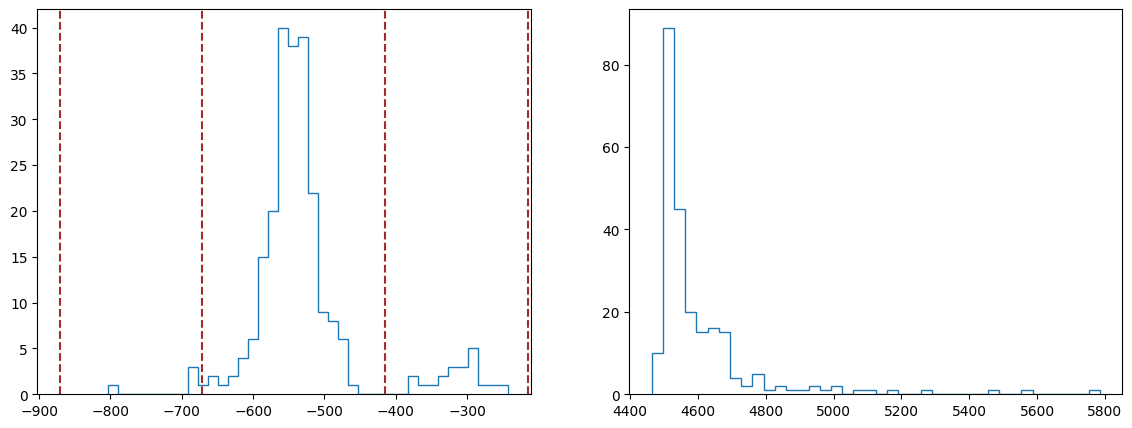

In [5]:
plt.figure(1, figsize = (14,5))
plt.subplot(1,2,1)

# Extract the mw dump markers
mw_cb_start, mw_cb_stop = ReadTheSpill(runs["Mirror A"], "\"Microwave Dump\"[0]") # Microwave DUMP
mask =  (dataset_mirrA["run time"] > mw_cb_start[0]) & (dataset_mirrA["run time"] < mw_cb_stop[0])

# Plot c state kickout
plt.hist(dataset_mirrA["Z"][mask], bins = 40, histtype = 'step')
plt.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
plt.axvline(zmax,linestyle = "--", color = "brown")
plt.axvline(zgap_min,linestyle = "--", color = "brown")
plt.axvline(zgap_max,linestyle = "--", color = "brown")
plt.subplot(1,2,2)
plt.hist(dataset_mirrA["run time"][mask], bins = 40, histtype = 'step')

cb_kickout.append(mask.sum()) # append to normalization array


# Extract the Z counts

mirror_start, mirror_stop = ReadTheSpill(runs["Mirror A"], "\"MAG rampdown\"[0]") # mirror dump
oct_start, oct_stop = ReadTheSpill(runs["Mirror A"], "\"Oc RampDown\"[0]") # mirror dump
Nup, Ndown = NupNdown(dataset_mirrA, oct_start[0] -150, oct_start[0], zmin, zmax, zgap_min, zgap_max)
print(Nup, Ndown)
mirros_ramps.append(Ndown)

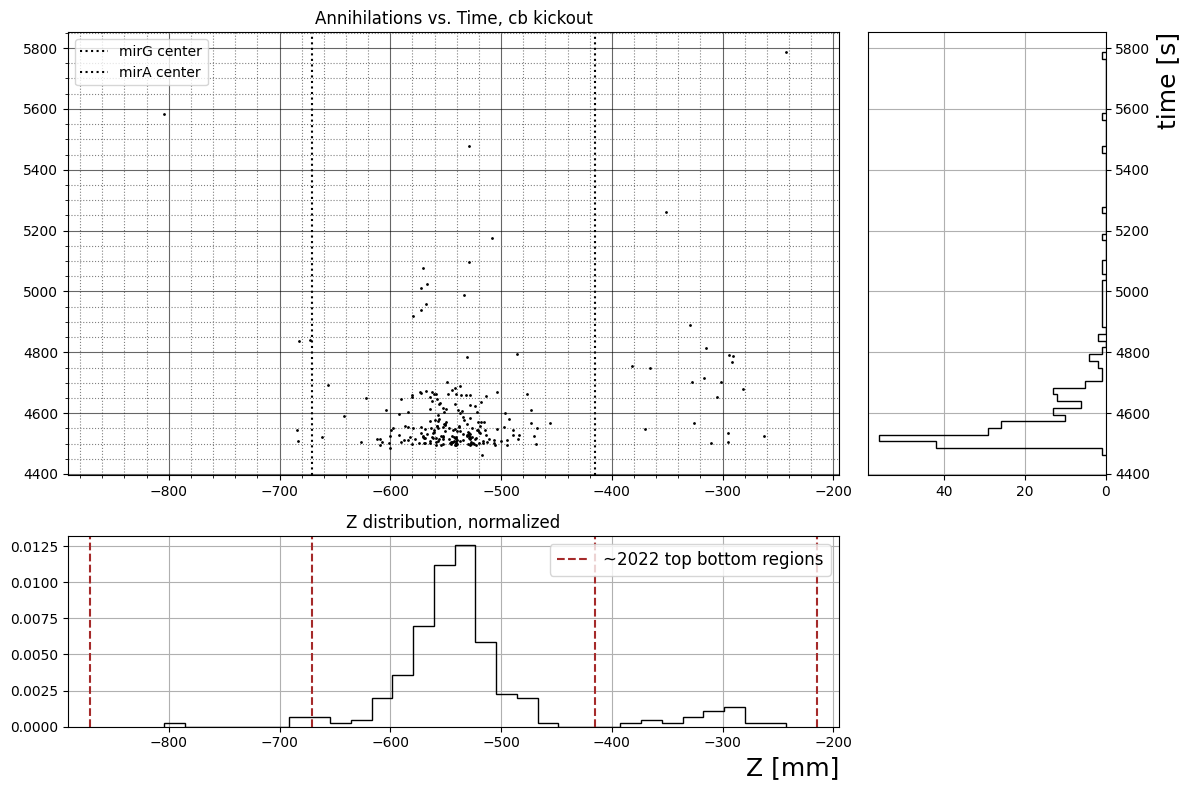

In [6]:
def NupNdown  (data, start, stop, zmin, zmax, zgap_min, zgap_max):
    Ndwn = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zmin) & (data["Z"] < zgap_min)
    Nup  = (data["run time"] > start) & (data["run time"] < stop) & (data["Z"] > zgap_max) & (data["Z"] < zmax)
    return Nup.sum(), Ndwn.sum()

mask   = (dataset_mirrA["run time"] > mw_cb_start[0]) & (dataset_mirrA["run time"] < mw_cb_stop[0])

Nup, Ndown = NupNdown(dataset_mirrA, mw_cb_start[0], mw_cb_stop[0], zmin, zmax, zgap_min, zgap_max)

Nup   -= bkg_up   * (mw_cb_start[0] - mw_cb_stop[0])
Ndown -= bkg_down * (mw_cb_start[0] - mw_cb_stop[0])

#S = Ndown/(Nup + Ndown)

fig = plt.figure(figsize=(12,8))

# griglia 4x1 (4 righe, 1 colonna)
ax1 = plt.subplot2grid( shape = (3,4), loc = (0,0), rowspan=2, colspan = 3)  # occuopa 3 righe
ax2 = plt.subplot2grid( shape = (3,4), loc = (2,0), colspan = 3)             # occuopa 1 riga
ax3 = plt.subplot2grid( shape = (3,4), loc = (0,3), rowspan = 2)             # occuopa 1 riga

ax1.errorbar(dataset_mirrA["Z"][mask], dataset_mirrA["run time"][mask] , color = "black", marker = ".", linestyle = "", markersize = 2)
ax1.axvline(mirG_center, linestyle = "dotted", color = "black", label = "mirG center")
ax1.axvline(mirA_center, linestyle = "dotted", color = "black", label = "mirA center")

ax1.set_title("Annihilations vs. Time, cb kickout")
ax1.set_xlim(zmin-20,zmax+20)
ax1.legend()
ax1.grid()
ax1.minorticks_on()
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia


ax2.set_title("Z distribution, normalized")
ax2.set_xlabel("Z [mm]", loc = "right", fontsize = 18)
ax2.hist(dataset_mirrA["Z"][mask], bins = 30, histtype = "step", color = "black", density = True)
ax2.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
ax2.axvline(zmax,linestyle = "--", color = "brown")
ax2.axvline(zgap_min,linestyle = "--", color = "brown")
ax2.axvline(zgap_max,linestyle = "--", color = "brown")
ax2.set_xlim(zmin-20,zmax+20)
ax2.legend(fontsize = 12)
ax2.grid()

counts, bins, _ = ax3.hist(dataset_mirrA["run time"][mask], bins = 60, histtype = "step",  color = "black", density = False,  orientation='horizontal')
xgrid = np.linspace(bins[4], bins[-1], 100)

#ax3.set_yticks([])
ax3.set_ylabel("time [s]", loc = "top", fontsize = 18)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.invert_xaxis()
ax3.grid()

plt.tight_layout()
plt.show()
#fig.savefig(f"MBMF_rampdown_ag{runs['2025'][0].split('/')[0].replace('ag','')}.png")

DetectorStudies/ag14247.vertex.csv
   [ 212.471- 318.574]= 106.103s |          "Oc RampDown"[0]            |   11110      597      585      366     5644     4404    13453     7802    21878        29 

103 1


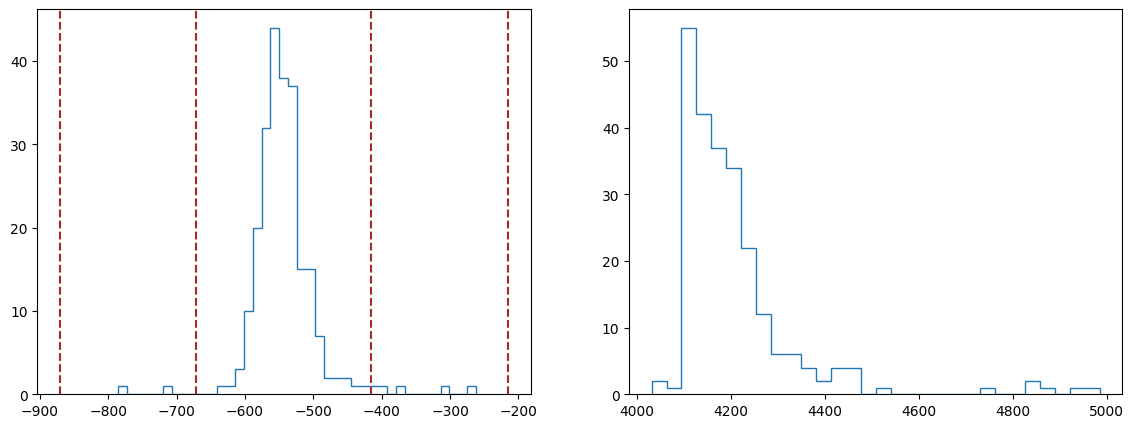

In [7]:
plt.figure(2, figsize = (14,5))
plt.subplot(1,2,1)

#mw_cb_start, mw_cb_stop = ReadTheSpill(runs["Miror G normalization"], "\"Microwave Dump\"[0]") # Microwave DUMP
#mask =  (dataset_norm["run time"] > mw_cb_start[0]) & (dataset_norm["run time"] < mw_cb_stop[0])
mask =  (dataset_norm["run time"] > 4000) & (dataset_norm["run time"] < 5000)

plt.hist(dataset_norm["Z"][mask], bins = 40, histtype = 'step')
plt.axvline(zmin,linestyle = "--", color = "brown", label = "~2022 top bottom regions")
plt.axvline(zmax,linestyle = "--", color = "brown")
plt.axvline(zgap_min,linestyle = "--", color = "brown")
plt.axvline(zgap_max,linestyle = "--", color = "brown")
plt.subplot(1,2,2)
plt.hist(dataset_norm["run time"][mask], bins = 30, histtype = 'step')

cb_kickout.append(mask.sum())

# Extract the Z counts

oct_start, oct_stop = ReadTheSpill(runs["Mirror G"], "\"Oc RampDown\"[0]") # Oct ramp down
Nup, Ndown = NupNdown(dataset_mirrG, oct_start[0] - 150, oct_start[0], zmin, zmax, zgap_min, zgap_max)
print(Nup, Ndown)
mirros_ramps.append(Nup)

In [8]:
print(cb_kickout)
print(mirros_ramps)

[238, 238]
[95, 103]


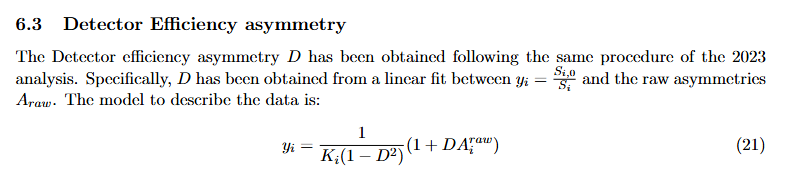

In [9]:
mirros_ramps = np.array(mirros_ramps)
cb_kickout = np.array(cb_kickout)

y = np.array(mirros_ramps)/np.array(cb_kickout)
x = np.array(Asymmetry)
print(y, x)

def ratio_with_error(A, sigma_A, B, sigma_B):
    R = A / B
    sigma_R = R * np.sqrt((sigma_A/A)**2 + (sigma_B/B)**2)
    return R, sigma_R

y, dy = ratio_with_error(mirros_ramps, np.sqrt(mirros_ramps) , cb_kickout, np.sqrt(cb_kickout))
print(y, dy)

ydown, dydown = y[0], dy[0]
yup, dyup     = y[1], dy[1]

z , dz = ratio_with_error(ydown, dydown, yup, dyup)
print(z, dz)

D = (1 - z)/(1 + z)
dD = 2 * dz/(1 + z**2)

print(f"Detector Efficiency Asymmetry, quick and dirty: {D:.3f} +/- {dD:.3f}")

[0.39915966 0.43277311] [-1  1]
[0.39915966 0.43277311] [0.0484416  0.05104232]
0.9223300970873787 0.15608489251429628
Detector Efficiency Asymmetry, quick and dirty: 0.040 +/- 0.169
